# Загрузка данных

Для начала мы скачаем датасет: [ADDI project](https://www.fc.up.pt/addi/ph2%20database.html).

<table><tr><td>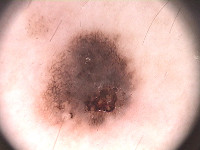</td><td>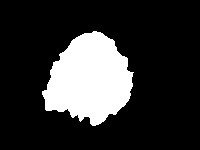</td></tr></table>


Это фотографии двух типов **поражений кожи:** меланома и родинки.


In [1]:
dataset_dir = '/content/PH2Dataset'
output_dir = '/content/'
path_to_dummy_samples = '/content/for_asserts/'
ckpt_path = '/content/ckpt/'
!mkdir /content/for_asserts
!mkdir /content/ckpt

In [2]:
!gdown 1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql
get_ipython().system_raw("unrar x PH2Dataset.rar")

Downloading...
From (original): https://drive.google.com/uc?id=1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql
From (redirected): https://drive.google.com/uc?id=1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql&confirm=t&uuid=4d1069cc-e34a-4902-9c4f-bd076344f589
To: /content/PH2Dataset.rar
100% 162M/162M [00:01<00:00, 134MB/s]


Стуктура датасета:

    IMD_002/
        IMD002_Dermoscopic_Image/
            IMD002.bmp
        IMD002_lesion/
            IMD002_lesion.bmp
        IMD002_roi/
            ...
    IMD_003/
        ...
        ...

 Здесь `X.bmp` — изображение, которое нужно сегментировать, `X_lesion.bmp` — результат сегментации.

Для загрузки датасета можно использовать skimage: [`skimage.io.imread()`](https://scikit-image.org/docs/dev/api/skimage.io.html)

In [3]:
images = []
lesions = []
from skimage.io import imread
import os
root = 'PH2Dataset'

for root, dirs, files in os.walk(dataset_dir):
    if root.endswith('_Dermoscopic_Image'):
        images.append(imread(os.path.join(root, files[0])))
    if root.endswith('_lesion'):
        lesions.append(imread(os.path.join(root, files[0])))

Изображения имеют разные размеры. Поэтому изменим их размер на $256\times256 $ пикселей. Для изменения размера изображений можно использовать [`skimage.transform.resize()`](https://scikit-image.org/docs/dev/api/skimage.transform.html#skimage.transform.resize).
Эта функция также автоматически нормализует изображения в диапазоне $[0,1]$.


In [4]:
from skimage.transform import resize
size = (256, 256)
X = [resize(x, size, mode='constant', anti_aliasing=True,) for x in images]
Y = [resize(y, size, mode='constant', anti_aliasing=False) > 0.5 for y in lesions]

In [5]:
import numpy as np
X = np.array(X, np.float32)
Y = np.array(Y, np.float32)
print(f'Loaded {len(X)} images')

Loaded 200 images


Чтобы убедиться, что все корректно, мы нарисуем несколько изображений

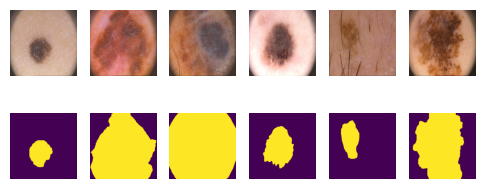

In [6]:
import matplotlib.pyplot as plt
from IPython.display import clear_output

plt.figure(figsize=(6, 6))
for i in range(6):
    plt.subplot(3, 6, i+1)
    plt.axis("off")
    plt.imshow(X[i])

    plt.subplot(4, 6, i+7)
    plt.axis("off")
    plt.imshow(Y[i])
plt.show();

Разделим наши 200 картинок на 120/40/40
 для обучения, валидации и теста соответственно

In [7]:
ix = np.random.choice(len(X), len(X), False)
tr, val, ts = np.split(ix, [120, 160])

## PyTorch DataLoader

In [8]:
from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset
batch_size = 10

train_dataloader = DataLoader(list(zip(np.rollaxis(X[tr], 3, 1), Y[tr, np.newaxis])),
                     batch_size=batch_size, shuffle=True, num_workers = 2)
valid_dataloader = DataLoader(list(zip(np.rollaxis(X[val], 3, 1), Y[val, np.newaxis])),
                      batch_size=batch_size, shuffle=False, num_workers = 2)
test_dataloader = DataLoader(list(zip(np.rollaxis(X[ts], 3, 1), Y[ts, np.newaxis])),
                     batch_size=batch_size, shuffle=False, num_workers = 2)

# Метрика

## IoU (intersection over union)

В данном разделе предлагается использовать следующую метрику для оценки качества:

$I o U=\frac{\text {target } \cap \text { prediction }}{\text {target } \cup{prediction }}$

Пересечение (A ∩ B) состоит из пикселей, найденных как в маске предсказания, так и в основной маске истины, тогда как объединение (A ∪ B) просто состоит из всех пикселей, найденных либо в маске предсказания, либо в целевой маске.


Что будет являться пересением и объединением в задаче сегментации?

Давайте разберем следующий пример:



In [9]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 27.6 MB/s eta 0:00:00


In [10]:
from torchmetrics import JaccardIndex

iou_score = JaccardIndex(threshold=0.5, task="binary", average='none').to("cuda")

# BCE Loss

Популярным лоссом для бинарной сегментации является *бинарная кросс-энтропия*, которая задается следующим образом:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right] \space [1]$$

где $y$ это  таргет желаемого результата и $\hat y$ является выходом модели. $\sigma$ - это [*логистическая* функция](https://en.wikipedia.org/wiki/Sigmoid_function), который преобразует действительное число $\mathbb R$ в вероятность $[0,1]$.

Однако эта потеря страдает от проблем численной нестабильности. Самое главное, что $\lim_{x\rightarrow0}\log(x)=\infty$ приводит к неустойчивости в процессе оптимизации. Рекомендуется посмотреть следующее [упрощение](https://www.tensorflow.org/api_docs/python/tf/nn/sigmoid_cross_entropy_with_logits). Эта функция эквивалентна первой и не так подвержена численной неустойчивости:

$$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right) \space [2]$$

### Реализация в коде оба варианта лосса



*   `bce_true()` - честная прямая реализация лосса с формулой $$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$
*   `bce_loss()` - реализация упрощенной формулы $$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right).$$

И сравним результаты функций с реализацией Pytorch:
*   `bce_torch()`
*   `bce_torch_with_logits()`

In [12]:
import torch
import torch.nn.functional as F
import torch.nn as nn

In [13]:
bce_torch = nn.BCELoss(reduction='sum') # (sigmoid(y_pred), y_real)
bce_torch_with_logits = nn.BCEWithLogitsLoss(reduction='sum')

In [14]:
def bce_loss(y_pred, y_real):
    return torch.sum(y_pred - y_pred * y_real + torch.log(1+torch.exp(-y_pred)))

def bce_true(y_pred, y_real):
    return -torch.sum(y_real*torch.log(torch.sigmoid(y_pred))+(1-y_real)*torch.log(1-torch.sigmoid(y_pred)))

Проверим корректность на простом примере

In [15]:
y_pred = torch.randn(3, 2, requires_grad=False)
y_true = torch.rand(3, 2, requires_grad=False)

print(f'BCE loss from scratch bce_loss = {bce_loss(y_pred, y_true)}')
print(f'BCE loss честно посчитанный = {bce_true(y_pred, y_true)}')
print(f'BCE loss from torch bce_torch = {bce_torch(torch.sigmoid(y_pred), y_true)}')
print(f'BCE loss from torch with logits bce_torch = {bce_torch_with_logits(y_pred, y_true)}')


BCE loss from scratch bce_loss = 3.351309061050415
BCE loss честно посчитанный = 3.351309061050415
BCE loss from torch bce_torch = 3.351309061050415
BCE loss from torch with logits bce_torch = 3.351308822631836


Инструкции `assert` в Python — это булевы выражения, которые проверяют, является ли условие истинным (`True`). Внизу в коде мы проверяем функция `bce_loss()` выдает тот же результат, что и функция из Pytorch или нет. Если равенства не будет, что будет означать, что результаты функций не совпадают, а значит вы неправильно реализовали фукнцию `bce_loss()`, `assert` возвратит ошибку.

Функция `numpy.isclose()` используется для сравнения двух чисел с учётом допустимой погрешности. Она особенно полезна при работе с числами с плавающей точкой, где точное сравнение может быть проблематичным из-за ограничений представления таких чисел в компьютере.

Как она работает?

`numpy.isclose(a, b, rtol=1e-05, atol=1e-08) `принимает два числа (`a` и `b`) и сравнивает их, учитывая относительную и абсолютную погрешность. Если разница между двумя числами меньше заданного порога, функция возвращает `True`, иначе — `False`.

Параметры:

    rtol: Относительная погрешность (по умолчанию 1e-05). Используется для определения разницы относительно большего значения.
    atol: Абсолютная погрешность (по умолчанию 1e-08). Определяет минимальную разницу, которую следует учитывать.

Мы будем использовать `assert` и `numpy.isclose()` для проверки корректности  кода.

In [16]:
assert np.isclose(bce_loss(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true))
assert np.isclose(bce_loss(y_pred, y_true), bce_torch_with_logits(y_pred, y_true))
assert np.isclose(bce_true(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true))
assert np.isclose(bce_true(y_pred, y_true), bce_torch_with_logits(y_pred, y_true))

Давайте теперь посчитаем на простом примере, но с теми же размерностями, что и в датасете

In [ ]:
[B, C, H, W]

In [17]:
y_pred = torch.randn((2, 1, 3, 3), requires_grad=False)
y_true = torch.randint(0, 2, (2, 1, 3, 3))

print(f'BCE loss from scratch bce_loss = {bce_loss(y_pred, y_true)}')
print(f'BCE loss честно посчитанный = {bce_true(y_pred, y_true)}')
print(f'BCE loss from torch bce_torch = {bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float))}')
print(f'BCE loss from torch with logits bce_torch = {bce_torch_with_logits(y_pred, y_true.to(torch.float))}')

BCE loss from scratch bce_loss = 15.179204940795898
BCE loss честно посчитанный = 15.179204940795898
BCE loss from torch bce_torch = 15.179204940795898
BCE loss from torch with logits bce_torch = 15.179204940795898


In [18]:
assert np.isclose(bce_loss(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float)))
assert np.isclose(bce_loss(y_pred, y_true), bce_torch_with_logits(y_pred, y_true.to(torch.float)))
assert np.isclose(bce_true(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float)))
assert np.isclose(bce_true(y_pred, y_true), bce_torch_with_logits(y_pred, y_true.to(torch.float)))

Давайте посчитаем на реальных логитах и сегментационной маске:

In [19]:
!gdown --folder 1EX0RW1TRQVkLmR1h6miCQqyhYPFyg28M

Retrieving folder contents
Processing file 1--WxvBdpMn_NOmYPf3a4au8MHzfx5baC labels.pt
Processing file 1-0A7_CS_vKiSCkgIDJ4joThCEcFedA3I logits.pt
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1--WxvBdpMn_NOmYPf3a4au8MHzfx5baC
To: /content/for_asserts/labels.pt
100% 1.18k/1.18k [00:00<00:00, 7.40MB/s]
Downloading...
From: https://drive.google.com/uc?id=1-0A7_CS_vKiSCkgIDJ4joThCEcFedA3I
To: /content/for_asserts/logits.pt
100% 1.18k/1.18k [00:00<00:00, 7.32MB/s]
Download completed


In [20]:

dummpy_sample = {'logits': torch.load(f'{path_to_dummy_samples}/logits.pt'),
                 'labels': torch.load(f'{path_to_dummy_samples}/labels.pt')}
dummpy_sample['labels'] = dummpy_sample['labels'].to("cuda")
dummpy_sample['logits'] = dummpy_sample['logits'].to("cuda")

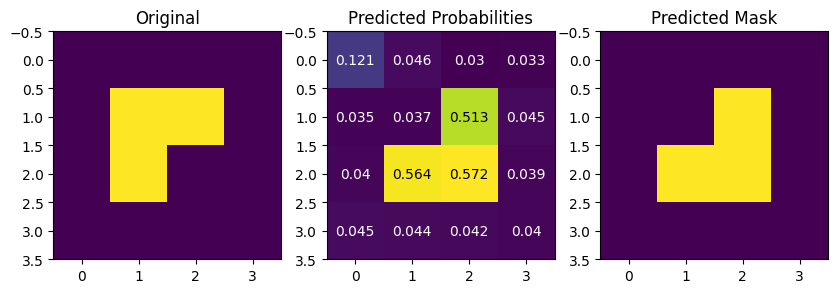

In [21]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize= (10,3*10))

ax1.imshow(dummpy_sample['labels'].squeeze(1)[0].cpu())
ax1.set_title("Original")

ax2.imshow(dummpy_sample['logits'].sigmoid().squeeze(1)[0].cpu())
for (j,i),label in np.ndenumerate(dummpy_sample['logits'].sigmoid().squeeze(1)[0].cpu()):
    if label < 0.5:
        color = 'white'
    else:
        color = 'black'
    ax2.text(i,j,round(label,3), color=color, ha='center',va='center')

ax2.set_title("Predicted Probabilities")

ax3.imshow((dummpy_sample['logits'].sigmoid() > 0.5).squeeze(1)[0].cpu())
ax3.set_title("Predicted Mask")
plt.show()

Проверяем на данном примере:

In [22]:
bce_loss_score = bce_loss(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu())
bce_true_score = bce_true(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu())
bce_torch_score = bce_torch(torch.sigmoid(dummpy_sample['logits'].cpu()), dummpy_sample['labels'].cpu().float())
bce_torch_with_logits_score = bce_torch_with_logits(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu().float())
assert np.isclose(bce_loss_score, bce_torch_score)
assert np.isclose(bce_loss_score, bce_torch_with_logits_score)
assert np.isclose(bce_true_score, bce_torch_score)
assert np.isclose(bce_true_score, bce_torch_with_logits_score)

# SegNet

Реалиация SegNet архитектуры.

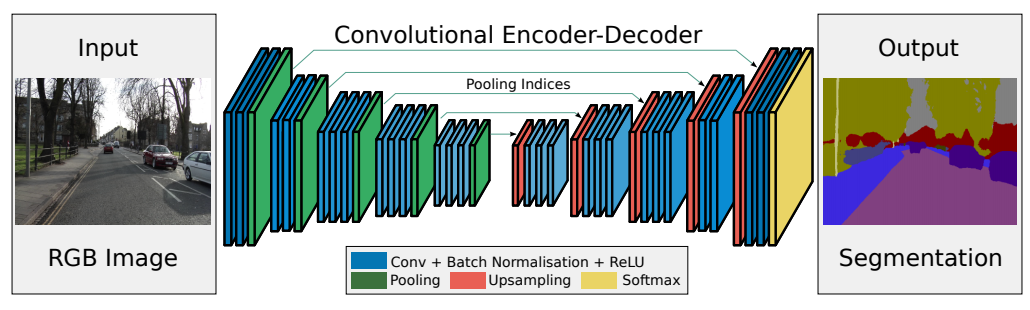

* Badrinarayanan, V., Kendall, A., & Cipolla, R. (2015). [SegNet: A deep convolutional
encoder-decoder architecture for image segmentation](https://arxiv.org/pdf/1511.00561.pdf)

In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
import torch.optim as optim
from time import time

from matplotlib import rcParams
rcParams['figure.figsize'] = (15,4)

Хорошие ресурсы по SegNet архитектуре:
1. https://medium.com/@nikdenof/segnet-from-scratch-using-pytorch-3fe9b4527239


In [25]:
class SegNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super().__init__()

        self.in_channels = in_channels
        self.out_channels = out_channels

        # кодер
        self.en_conv0 = nn.Sequential(
            nn.Conv2d(self.in_channels, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        self.MaxEn0 = nn.MaxPool2d(2, stride=2, return_indices=True)

        self.en_conv1 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )
        self.MaxEn1 = nn.MaxPool2d(2, stride=2, return_indices=True)

        self.en_conv2 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU()
        )
        self.MaxEn2 = nn.MaxPool2d(2, stride=2, return_indices=True)

        self.en_conv3 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU()
        )
        self.MaxEn3 = nn.MaxPool2d(2, stride=2, return_indices=True)

        # # боттлнек вариант 1
        # self.bottleneck_conv = nn.Sequential(
        #     nn.Conv2d(512, 256, kernel_size=3, padding=1),
        #     nn.BatchNorm2d(256),
        #     nn.ReLU(),
        #     nn.Conv2d(256, 128, kernel_size=3, padding=1),
        #     nn.BatchNorm2d(128),
        #     nn.ReLU(),
        #     nn.Conv2d(128, 256, kernel_size=3, padding=1),
        #     nn.BatchNorm2d(256),
        #     nn.ReLU(),
        #     nn.Conv2d(256, 512, kernel_size=3, padding=1),
        #     nn.BatchNorm2d(512),
        #     nn.ReLU()
        # )

        # боттлнек вариант 2
        self.bottleneck_conv = nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU()
        )

        # декодер
        self.MaxUnDe3 = nn.MaxUnpool2d(2, stride=2)
        self.de_conv3 = nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(512, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU()
        )

        self.MaxUnDe2 = nn.MaxUnpool2d(2, stride=2)
        self.de_conv2 = nn.Sequential(
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )

        self.MaxUnDe1 = nn.MaxUnpool2d(2, stride=2)
        self.de_conv1 = nn.Sequential(
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )

        self.MaxUnDe0 = nn.MaxUnpool2d(2, stride=2)
        self.de_conv0 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, self.out_channels, kernel_size=3, padding=1),
        )

    def forward(self, x):
        # слои кодера
        en0, ind_e0 = self.MaxEn0(self.en_conv0(x))
        en1, ind_e1 = self.MaxEn1(self.en_conv1(en0))
        en2, ind_e2 = self.MaxEn2(self.en_conv2(en1))
        en3, ind_e3 = self.MaxEn3(self.en_conv3(en2))

        # боттлнек
        d3 = self.bottleneck_conv(en3)

        # слои декодера
        d2 = self.de_conv3(self.MaxUnDe3(d3,ind_e3))
        d1 = self.de_conv2(self.MaxUnDe2(d2,ind_e2))
        d0 = self.de_conv1(self.MaxUnDe1(d1,ind_e1))
        logits = self.de_conv0(self.MaxUnDe0(d0,ind_e0))

        return logits

In [26]:
segnet_model = SegNet().to('cuda')
segnet_model

SegNet(
  (en_conv0): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
  )
  (MaxEn0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (en_conv1): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
  )
  (MaxEn1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (en_conv2): Sequential(
    (0):

## обучение модели



In [27]:
from tqdm.notebook import tqdm

In [ ]:
def train(model, epochs, train_dataloader, val_dataloader, optimizer, criterion, scheduler, metric, model_name):
    history = []

    best_val_loss = float('inf')
    best_val_iou = 0

    for epoch in tqdm(range(epochs)):
        train_loss, train_metric = fit_epoch(model, train_dataloader, optimizer,criterion,scheduler, metric, epoch)

        if val_dataloader!= None:
            val_loss, val_metric = eval_epoch(model,val_dataloader, criterion, metric)
        else:
            val_loss, val_metric = None, None

        lr = scheduler.get_last_lr()[0]
        history.append({
            'epoch':epoch,
            'train_loss':train_loss,
            'train_metric':train_metric,
            'val_loss':val_loss,
            'val_metric':val_metric,
            'lr':lr,
            'model_name':model_name
        })

        if val_dataloader!= None:
            tqdm.write(f'ep= {epoch + 1},{train_loss = :.1f}, {train_metric = :.3f},{val_loss = :.1f}, {val_metric = :.3f}, {lr = :.5f}')
            # сохраняем параметры модели если лосс ниже наименьшего за предыдущие эпохи
            if val_loss<best_val_loss:
                best_val_loss = val_loss
                # сохраняем параметры модели
                torch.save(model.state_dict(), f'{ckpt_path}{model_name}_best_val.pt')
        else:
            tqdm.write(f'ep={epoch + 1},{train_loss = :.1f}, {train_metric = :.3f}, lr=lr')

    return history


In [ ]:
from torch.optim import lr_scheduler

def fit_epoch(model, train_dataloader, optimizer, criterion, scheduler, metric, epoch):

    model.train()
    avg_loss = 0.0
    avg_metric = 0.0
    for inputs, labels in train_dataloader:
    #for inputs, labels in tqdm(train_dataloader, desc=f"Epoch {epoch + 1}"):
        inputs = inputs.to('cuda')
        labels = labels.to('cuda')
        optimizer.zero_grad()

        logits = model(inputs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        avg_loss += loss.item()
        avg_metric += metric(logits, labels).item()

    scheduler.step()

    avg_loss = avg_loss/len(train_dataloader)
    avg_metric = avg_metric/len(train_dataloader)

    # почистим память GPU
    torch.cuda.empty_cache()
    return avg_loss, avg_metric

In [ ]:
def eval_epoch(model,val_dataloader, criterion, metric, plot=False):
    model.eval()

    avg_loss = 0
    avg_metric = 0.0

    with torch.no_grad():
      for inputs, labels in tqdm(valid_dataloader):
          inputs = inputs.to('cuda')
          labels = labels.to('cuda')

          logits = model(inputs)

          avg_loss += criterion(logits, labels).item()
          avg_metric += metric(logits, labels).item()

    avg_loss = avg_loss/len(valid_dataloader)
    avg_metric = avg_metric/len(valid_dataloader)

    # почистим память GPU
    torch.cuda.empty_cache()



    return avg_loss, avg_metric

In [28]:
import pandas as pd
import seaborn as sns
def display_metrics(history):
    df = pd.DataFrame(history)
    model_name = history[0]['model_name']
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.lineplot(data=df, x='epoch', y='train_loss', ax=axes[0], label='Train')
    sns.lineplot(data=df, x='epoch', y='val_loss', ax=axes[0], label='Validation')
    axes[0].set_title(f'Loss over Epochs for {model_name}')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')

    sns.lineplot(data=df, x='epoch', y='train_metric', ax=axes[1], label='Train')
    sns.lineplot(data=df, x='epoch', y='val_metric', ax=axes[1], label='Validation')
    axes[1].set_title(f'Metric over Epochs for {model_name}')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Metric')

    plt.tight_layout()
    plt.show()

## SegNet на BCE Loss

In [ ]:
current_model = SegNet(3,1).to('cuda')
model_name = 'SegNet_ВСЕ_loss'
optimizer = torch.optim.Adam(current_model.parameters(), lr = 2e-4, amsgrad = True)
criterion = bce_loss
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma = 0.95)
metric = iou_score
epochs = 10

In [ ]:
history_segnet_bce_loss = train(current_model, epochs, train_dataloader, valid_dataloader, optimizer,criterion,scheduler,metric, model_name)

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

ep= 1,train_loss = 350137.8, train_metric = 0.547,val_loss = 432924.8, val_metric = 0.000, lr = 0.00019


  0%|          | 0/4 [00:00<?, ?it/s]

ep= 2,train_loss = 239333.7, train_metric = 0.681,val_loss = 446376.0, val_metric = 0.019, lr = 0.00018


...

ep= 8,train_loss = 130686.5, train_metric = 0.784,val_loss = 151854.3, val_metric = 0.757, lr = 0.00013


  0%|          | 0/4 [00:00<?, ?it/s]

ep= 9,train_loss = 124722.2, train_metric = 0.792,val_loss = 149121.0, val_metric = 0.777, lr = 0.00013


  0%|          | 0/4 [00:00<?, ?it/s]

ep= 10,train_loss = 139074.7, train_metric = 0.762,val_loss = 145313.0, val_metric = 0.777, lr = 0.00012


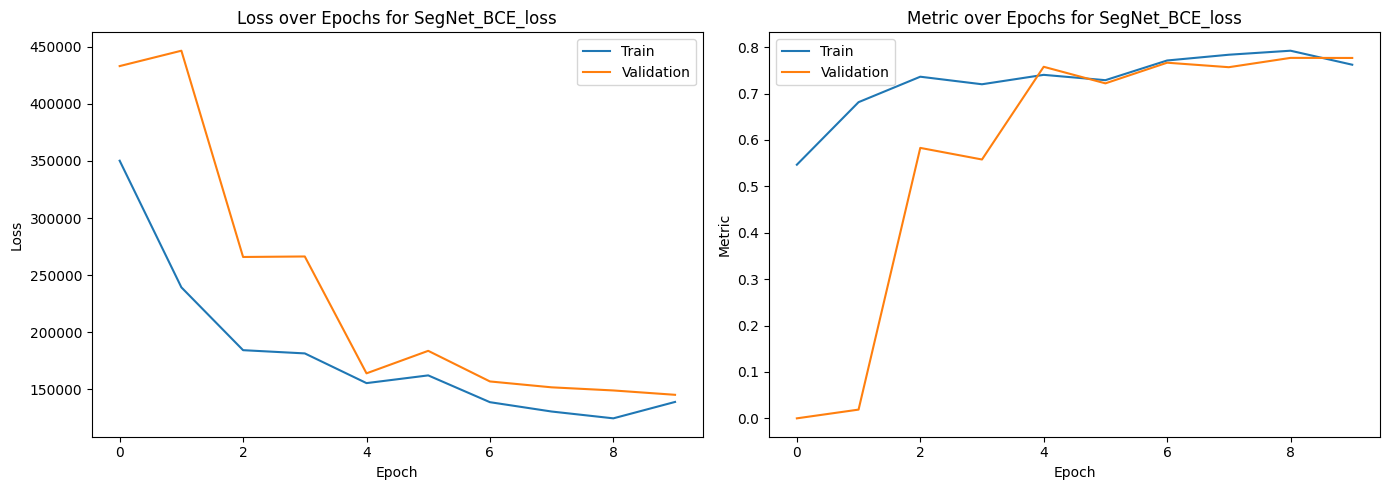

In [ ]:
import warnings

warnings.filterwarnings('ignore')
display_metrics(history_segnet_bce_loss)

## Инференс



In [ ]:
best_model_saved_filename = f'{ckpt_path}{model_name}_best_val.pt'
best_model_saved_filename

'/content/ckpt/SegNet_ВСЕ_loss_best_val.pt'

In [ ]:
# читаем из файла состояние модели
best_state_dict = torch.load(best_model_saved_filename)
# загружаем его в модель
current_model = SegNet().to('cuda')
current_model.load_state_dict(best_state_dict)
segnet_bce_loss_model = current_model

In [ ]:
# обработка снимка
def predict(model, test_dataloader):
    torch.cuda.empty_cache()
    model.eval()
    with torch.no_grad():
        inputs = test_dataloader
        for inputs, labels in test_dataloader:
            inputs = inputs.to('cuda')
            labels = labels.to('cuda')

            logits = model(inputs)
            Y_pred = (torch.sigmoid(logits)>0.5).cpu().int().numpy()

    return inputs.cpu().permute(0,2,3,1), Y_pred[:,0,:,:], labels.cpu()[:,0,:,:]



In [ ]:
# считаем произвольную метрику
def score_model(model, metric, data):
    model.eval()  # testing mode
    scores = 0

    for X_batch, Y_label in data:
        Y_pred = (model(X_batch.to('cuda')) > 0.5).int()
        scores += metric(Y_label.to('cuda'), Y_pred).mean().item()
    return scores/len(data)

In [ ]:
# отрисовка
def print_BADNEWS(X, Y_pred, Y_real):
    print('Исходное изображение|Полученная сегментация|Таргет')
    N_ris = len(Y_pred)

    plt.figure(figsize=(4, 10))
    for i in range(N_ris):
        plt.subplot(N_ris, 3, i*3+1)
        plt.axis("off")
        plt.imshow(X[i])


        plt.subplot(N_ris, 3, i*3+2)
        plt.axis("off")
        plt.imshow(Y_pred[i])

        plt.subplot(N_ris, 3, i*3+3)
        plt.axis("off")
        plt.imshow(Y_real[i])
    plt.show();

Метрика для модели SegNet_ВСЕ_loss равна 0.7713185399770737
Исходное изображение|Полученная сегментация|Таргет


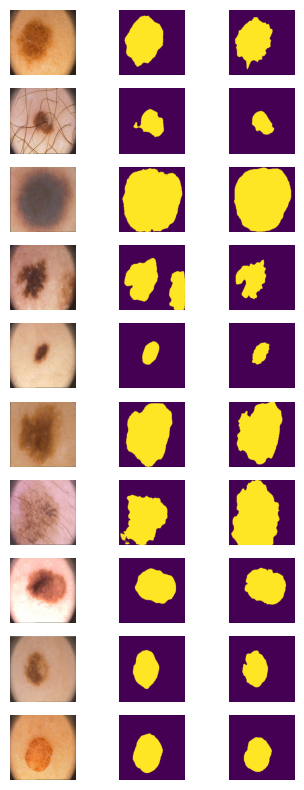

In [ ]:
X,Y_pred, Y_real = predict(current_model, test_dataloader)
print(f'Метрика для модели {model_name} равна {score_model(current_model, metric,test_dataloader)}')
print_BADNEWS(X, Y_pred, Y_real)
del current_model

# Дополнительные функции потерь

### Dice Loss

**1. Dice coefficient:** Учитывая две маски $X$ и $Y$, общая метрика для измерения расстояния между этими двумя масками задается следующим образом:

$$D(X,Y)=\frac{2|X\cap Y|}{|X|+|Y|}$$

В терминах матрицы ошибок она будет считаться следующим образом:

$$D(X,Y) = \frac{2TP}{2TP + FP + FN}$$

Эта функция не является дифференцируемой, но это необходимое свойство для градиентного спуска. В данном случае мы можем приблизить его с помощью:

$$\mathcal L_D(X,Y) = 1- D(X, Y)$$

**Hints** (!):

1. Не забудьте подумать о численной нестабильности, возникающей в математической формуле при ситуации, когда $\frac{0}{0}$, т.е. вам нужно добавить очень маленькое число, например $\epsilon = 1e^{-8}$, в обе части дроби при подсчете $D(X,Y)$:

$$D(X,Y) = \frac{2TP + ϵ}{2TP + FP + FN + ϵ}$$

2. Dice метрика(!), не лосс, считается похожим образом как IoU:

    2.1. На вход вам приходят logits, т.е. значения от $-∞$ до $∞$. Их переводим в вероятности от 0 до 1 при помощи функции Sigmoid.

    2.2. Фиксируем порог, например threshold=0.5, и всему что ниже порога ставим значение 0, всему что выше 1. Получаем предсказанную маску из 0 и 1.

    2.3. Считаем TP, FP, FN

    2.4. Считаем DICE метрику по формуле

Вы можете прописать для себя функцию `dice_score()` и сравнить с результатами работы функции из библиотеки `torchmetrics`.

3. Но с метрикой есть проблема, что она не дифференцируема, и если вы захотите просто взять и прописать `dice_loss` = 1 - `dice_score`, Pytorch поругается на вас и скажет, что это недифференцируемая метрика. Чтобы посчитать dice_loss делаем следующие шаги:

    3.1. На вход вам приходят logits, т.е. значения от $-∞$ до $∞$. Их переводим в вероятности от 0 до 1 при помощи функции Sigmoid.

    3.2. Здесь нам уже не нужно фиксировать порог, мы просто работаем с вероятностями. Значения вероятностей дифференцируемы и через них будут протекать градиенты.

    3.3. Считаем TP, FP, FN также как и в Dice метрике, только вместо маски, подаем вероятности.

    3.4. Считаем DICE метрику по формуле

    3.5. Считаем лосс как Loss = 1 - DICE

Итак, давайте сначала пропишем dice_score.

In [ ]:
def dice_score(logits: torch.Tensor, labels: torch.Tensor, threshold: float = 0.5, eps: float = 1e-8):
    '''
    Это именно метрика, не лосс.
    '''
    Y_pred = (torch.sigmoid(logits)>threshold).int()
    # вариант 1
    return 2 * torch.sum(Y_pred * labels)/(torch.sum(Y_pred)+torch.sum(labels)+eps)
    # вариант 2
    # TP = (Y_pred * labels).sum()
    # FP = torch.relu(labels-Y_pred).sum() # используем ReLU чтобы обнулить отрицательные значения
    # FN = torch.relu(Y_pred-labels).sum() # используем ReLU чтобы обнулить отрицательные значения
    # return 2 * (TP+eps)/(2*TP +FP+FN+ eps)

Проверим на корректность функцию dice_score:

In [ ]:
#from torchmetrics.classification import Dice # в актуальной версии torchmetrics.classification нет Dice
from torchmetrics.segmentation import DiceScore

dice = DiceScore(average='micro', num_classes = 1).to('cuda')
# dice(dummpy_sample['logits'].sigmoid(), dummpy_sample['labels'].to(int)) - ошибка авторов курса


In [ ]:
dice(dummpy_sample['logits'].sigmoid()>0.5, dummpy_sample['labels'].to(int)).item()

0.6666666865348816

In [ ]:
dice_score(dummpy_sample['logits'], dummpy_sample['labels']).item()

0.6666666865348816

In [ ]:
assert dice(dummpy_sample['logits'].sigmoid()>0.5, dummpy_sample['labels'].to(int)) == dice_score(dummpy_sample['logits'], dummpy_sample['labels'])

Давайте теперь пропишем лосс и воспользуемся библиотекой `segmentation-models-pytorch`, чтобы убедиться в корректности нашей функции.

In [ ]:
def dice_loss(logits: torch.Tensor, labels: torch.Tensor, eps: float = 1e-8):
    probs = logits.sigmoid()
    TP = torch.sum(probs *labels)
    FP = torch.sum(probs * (1 - labels))
    FN = torch.sum((1 - probs) * labels)
    return 1 - 2 * TP/(2* TP + FN +FP + eps)

Проверка на корректность:

In [ ]:
!pip install segmentation_models_pytorch # без установки не работает
from segmentation_models_pytorch.losses import DiceLoss
dice_loss_torch = DiceLoss(mode='binary', eps = 1e-8)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 10.8 MB/s eta 0:00:00


In [ ]:
dice_loss_torch(dummpy_sample['logits'], dummpy_sample['labels']).item()

0.5755997896194458

In [ ]:
dice_loss(dummpy_sample['logits'], dummpy_sample['labels']).item()

0.5755997896194458

In [ ]:
assert dice_loss_torch(dummpy_sample['logits'], dummpy_sample['labels']) == dice_loss(dummpy_sample['logits'], dummpy_sample['labels'])

### Focal Loss

[**2. Focal loss:**](https://arxiv.org/pdf/1708.02002.pdf)

Окей, мы уже с вами умеем делать BCE loss:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

Проблема с этой потерей заключается в том, что она имеет тенденцию приносить пользу классу **большинства** (фоновому) по отношению к классу **меньшинства** ( переднему). Поэтому обычно применяются весовые коэффициенты к каждому классу:

$$\mathcal L_{wBCE}(y, \hat y) = -\sum_i \alpha_i\left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

Традиционно вес $\alpha_i$ определяется как обратная частота класса этого пикселя $i$, так что наблюдения миноритарного класса весят больше по отношению к классу большинства.


Из оригинальной статьи по [Focal Loss](https://arxiv.org/pdf/1708.02002.pdf):

$$p_t = \sigma(\hat y_i)y_i + (1 - \sigma(\hat y_i)) (1-y_i)$$

$$\mathcal L_{focal}(y, \hat y) = (1 - p_t)^{\gamma} \mathcal L_{BCE}(y_i, \hat y_i).$$

$$\mathcal L_{focal}(y, \hat y) = -\sum_i (1 - p_t)^{\gamma} \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

$$\mathcal L_{focal}(y, \hat y) = -\sum_i (1 - (\sigma(\hat y_i)y_i + (1 - \sigma(\hat y_i)) (1-y_i)))^{\gamma} \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

In [ ]:
def focal_loss(inputs: torch.Tensor, targets: torch.Tensor, alpha: float = 0.25, gamma: float = 2):

    assert (0 <= alpha <= 1) or alpha == -1,'Некорректное значение alpha'
    probs = torch.sigmoid(inputs)
    ce_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction="none")
    p_t = probs * targets + (1 - probs) * (1 - targets)
    loss = ce_loss * ((1 - p_t) ** gamma)

    if alpha >= 0: # если альфа = -1 не балансируем, если от 0 до 1 то делаем перебалансировку таргета
        alpha_t = alpha * targets + (1 - alpha) * (1 - targets)
        loss = (alpha_t * loss)

    return loss.sum()

Проверка корректности функции:

In [ ]:
from torchvision.ops import sigmoid_focal_loss
sigmoid_focal_loss(dummpy_sample['logits'], dummpy_sample['labels'], alpha=-1, gamma=2, reduction='sum').item()

3.616123676300049

In [ ]:
focal_loss(dummpy_sample['logits'], dummpy_sample['labels'], alpha=-1, gamma = 2).item()

3.616123676300049

In [ ]:
assert sigmoid_focal_loss(dummpy_sample['logits'], dummpy_sample['labels'], alpha=-1, gamma=2, reduction='sum').item() == focal_loss(dummpy_sample['logits'], dummpy_sample['labels'], alpha=-1, gamma = 2).item()

[**3. Tversky loss function:**](https://arxiv.org/abs/1706.05721)

In [ ]:
def tversky_loss(logits: torch.Tensor, labels: torch.Tensor, alpha: float = 0.65, beta: float = 0.35, eps: float = 1e-8):
    probs = logits.sigmoid()
    TP = torch.sum(probs *labels)
    FP = torch.sum(probs * (1 - labels))
    FN = torch.sum((1 - probs) * labels)
    return 1 - TP/(TP + alpha * FN +beta * FP + eps)


In [ ]:
tversky_loss(dummpy_sample['logits'], dummpy_sample['labels']) # результат отличается, потому что по умолчанию сделал с alpha = 0.8 и beta = 0.2

tensor(0.5931, device='cuda:0')

In [ ]:
# при alpha = 0.5 и beta = 0.5 лосс совпадает с Dice loss. Но учиться будем с alpha = 0.8 и beta = 0.2
assert dice_loss_torch(dummpy_sample['logits'], dummpy_sample['labels']) == tversky_loss(dummpy_sample['logits'], dummpy_sample['labels'],alpha=0.5, beta=0.5)

# SegNet на Tversky Loss

In [ ]:
torch.cuda.empty_cache()
current_model = SegNet(3,1).to('cuda')
model_name = 'SegNet_Tversky_Loss'
optimizer = torch.optim.Adam(current_model.parameters(), lr = 2e-4, amsgrad = True)
criterion = tversky_loss
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma = 0.95)
metric = iou_score
epochs = 10

In [ ]:
history_segnet_tversky_loss = train(current_model, epochs, train_dataloader, valid_dataloader, optimizer,criterion,scheduler,metric, model_name)

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

ep= 1,train_loss = 0.4, train_metric = 0.511,val_loss = 0.6, val_metric = 0.000, lr = 0.00019


  0%|          | 0/4 [00:00<?, ?it/s]

ep= 2,train_loss = 0.3, train_metric = 0.642,val_loss = 0.7, val_metric = 0.000, lr = 0.00018


...

ep= 8,train_loss = 0.2, train_metric = 0.723,val_loss = 0.2, val_metric = 0.745, lr = 0.00013


  0%|          | 0/4 [00:00<?, ?it/s]

ep= 9,train_loss = 0.2, train_metric = 0.747,val_loss = 0.1, val_metric = 0.764, lr = 0.00013


  0%|          | 0/4 [00:00<?, ?it/s]

ep= 10,train_loss = 0.2, train_metric = 0.744,val_loss = 0.2, val_metric = 0.755, lr = 0.00012


In [ ]:
best_model_saved_filename = f'{ckpt_path}{model_name}_best_val.pt'
best_model_saved_filename

'/content/ckpt/SegNet_Tversky_Loss_best_val.pt'

In [ ]:
# читаем из файла состояние модели
best_state_dict = torch.load(best_model_saved_filename)
# загружаем его в модель
current_model = SegNet().to('cuda')
current_model.load_state_dict(best_state_dict)
segnet_tversky_loss_model = current_model

Метрика для модели SegNet_Tversky_Loss равна 0.7693913578987122
Исходное изображение|Полученная сегментация|Таргет


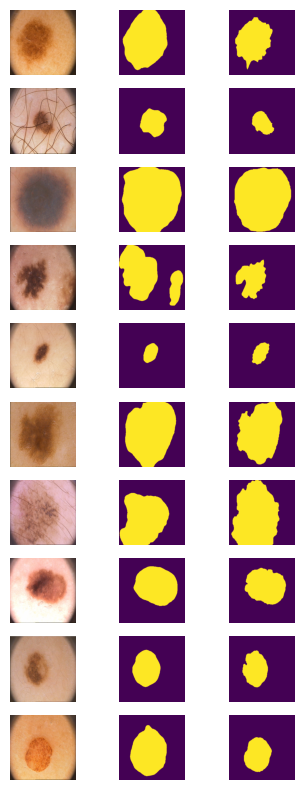

In [ ]:
X,Y_pred, Y_real = predict(current_model, test_dataloader)
print(f'Метрика для модели {model_name} равна {score_model(current_model, metric,test_dataloader)}')
print_BADNEWS(X, Y_pred, Y_real)
del current_model

## Обучение SegNet на других лоссах

# SegNet на Dice Loss

In [ ]:
torch.cuda.empty_cache()
current_model = SegNet(3,1).to('cuda')
model_name = 'SegNet_Dice_Loss'
optimizer = torch.optim.Adam(current_model.parameters(), lr = 2e-4, amsgrad = True)
criterion = dice_loss
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma = 0.95)
metric = iou_score
epochs = 10

In [ ]:
history_segnet_dice_loss = train(current_model, epochs, train_dataloader, valid_dataloader, optimizer,criterion,scheduler,metric, model_name)

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

ep= 1,train_loss = 0.5, train_metric = 0.511,val_loss = 0.6, val_metric = 0.000, lr = 0.00019


  0%|          | 0/4 [00:00<?, ?it/s]

ep= 2,train_loss = 0.3, train_metric = 0.706,val_loss = 0.7, val_metric = 0.007, lr = 0.00018


...

ep= 8,train_loss = 0.2, train_metric = 0.737,val_loss = 0.2, val_metric = 0.683, lr = 0.00013


  0%|          | 0/4 [00:00<?, ?it/s]

ep= 9,train_loss = 0.1, train_metric = 0.781,val_loss = 0.2, val_metric = 0.755, lr = 0.00013


  0%|          | 0/4 [00:00<?, ?it/s]

ep= 10,train_loss = 0.2, train_metric = 0.762,val_loss = 0.1, val_metric = 0.786, lr = 0.00012


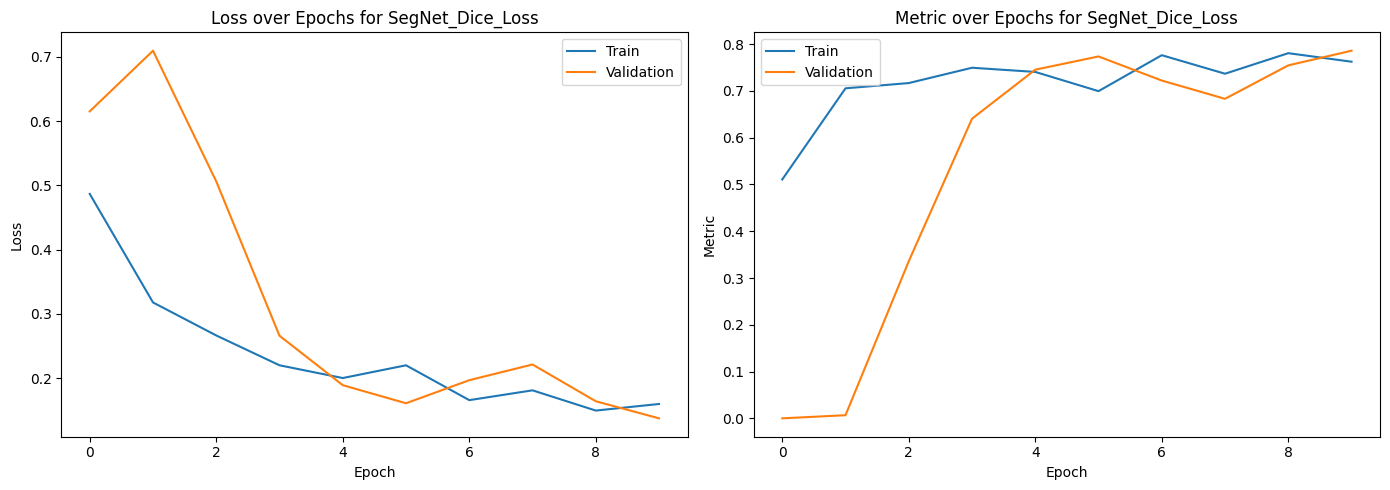

In [ ]:
display_metrics(history_segnet_dice_loss)

In [ ]:
best_model_saved_filename = f'{ckpt_path}{model_name}_best_val.pt'
best_model_saved_filename

'/content/ckpt/SegNet_Dice_Loss_best_val.pt'

In [ ]:
# читаем из файла состояние модели
best_state_dict = torch.load(best_model_saved_filename)
# загружаем его в модель
current_model = SegNet().to('cuda')
current_model.load_state_dict(best_state_dict)
segnet_dice_loss_model = current_model

Метрика для модели SegNet_Dice_Loss равна 0.7848962694406509
Исходное изображение|Полученная сегментация|Таргет


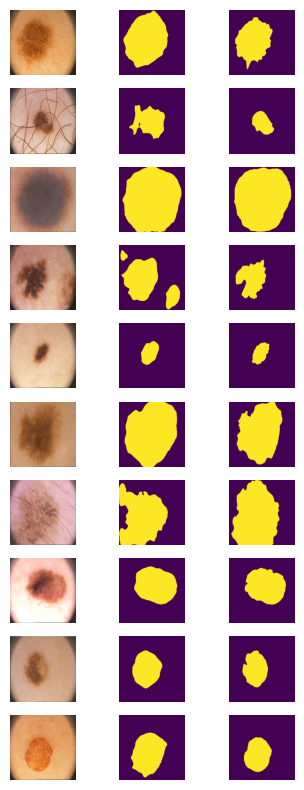

In [ ]:
X,Y_pred, Y_real = predict(current_model, test_dataloader)
print(f'Метрика для модели {model_name} равна {score_model(current_model, metric,test_dataloader)}')
print_BADNEWS(X, Y_pred, Y_real)
del current_model

# SegNet на Focal Loss

In [ ]:
torch.cuda.empty_cache()
current_model = SegNet(3,1).to('cuda')
model_name = 'SegNet_Focal_Loss'
optimizer = torch.optim.Adam(current_model.parameters(), lr = 2e-4, amsgrad = True)
criterion = focal_loss
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma = 0.95)
metric = iou_score
epochs = 10

In [ ]:
history_segnet_focal_loss = train(current_model, epochs, train_dataloader, valid_dataloader, optimizer,criterion,scheduler,metric, model_name)

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

ep= 1,train_loss = 47363.1, train_metric = 0.420,val_loss = 52587.7, val_metric = 0.000, lr = 0.00019


  0%|          | 0/4 [00:00<?, ?it/s]

ep= 2,train_loss = 23649.5, train_metric = 0.615,val_loss = 42032.7, val_metric = 0.000, lr = 0.00018


...

ep= 8,train_loss = 12393.3, train_metric = 0.746,val_loss = 15992.8, val_metric = 0.726, lr = 0.00013


  0%|          | 0/4 [00:00<?, ?it/s]

ep= 9,train_loss = 13213.0, train_metric = 0.764,val_loss = 13268.6, val_metric = 0.700, lr = 0.00013


  0%|          | 0/4 [00:00<?, ?it/s]

ep= 10,train_loss = 14432.8, train_metric = 0.666,val_loss = 14900.0, val_metric = 0.594, lr = 0.00012


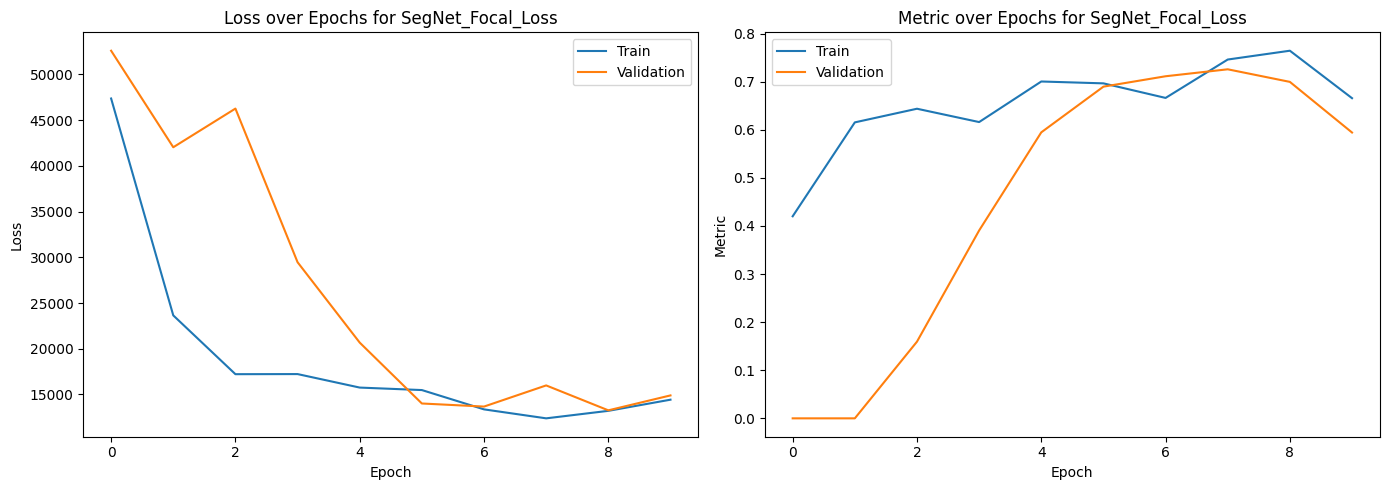

In [ ]:
display_metrics(history_segnet_focal_loss)

In [ ]:
best_model_saved_filename = f'{ckpt_path}{model_name}_best_val.pt'
best_model_saved_filename

'/content/ckpt/SegNet_Focal_Loss_best_val.pt'

In [ ]:
# читаем из файла состояние модели
best_state_dict = torch.load(best_model_saved_filename)
# загружаем его в модель
current_model = SegNet().to('cuda')
current_model.load_state_dict(best_state_dict)
segnet_focal_loss_model = current_model

Метрика для модели SegNet_Focal_Loss равна 0.6006049811840057
Исходное изображение|Полученная сегментация|Таргет


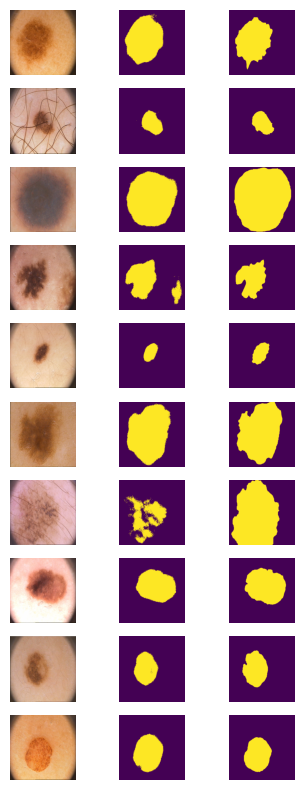

In [ ]:
X,Y_pred, Y_real = predict(current_model, test_dataloader)
print(f'Метрика для модели {model_name} равна {score_model(current_model, metric,test_dataloader)}')
print_BADNEWS(X, Y_pred, Y_real)
del current_model

# Сравнение результатов

In [ ]:
model_list = [segnet_bce_loss_model,segnet_dice_loss_model,segnet_focal_loss_model,segnet_tversky_loss_model]
model_name_list = ['SegNet_bce_loss','SegNet_dice_loss','SegNet_focal_loss','SegNet_Tversky_loss']
for i, model in enumerate(model_list):
    print(f'Метрика для модели {model_name_list[i]} на тестовой выборке равна {score_model(model, metric,test_dataloader)}')

Метрика для модели SegNet_bce_loss на тестовой выборке равна 0.7713185399770737
Метрика для модели SegNet_dice_loss на тестовой выборке равна 0.7848962694406509
Метрика для модели SegNet_focal_loss на тестовой выборке равна 0.6006049811840057
Метрика для модели SegNet_Tversky_loss на тестовой выборке равна 0.7693913578987122


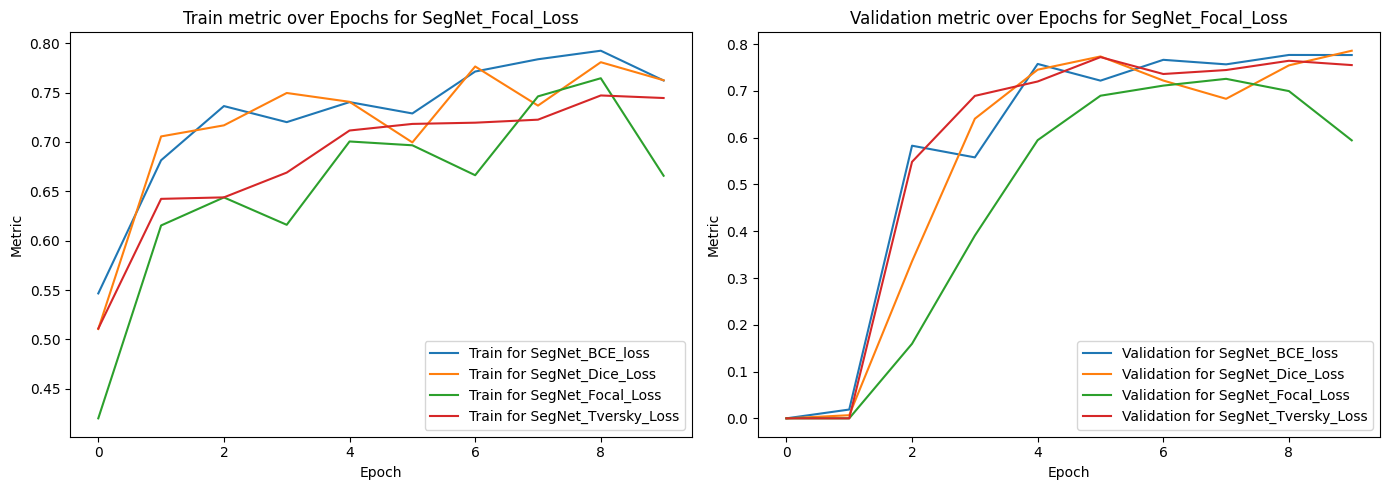

In [ ]:
history_list = [history_segnet_bce_loss,history_segnet_dice_loss,history_segnet_focal_loss,history_segnet_tversky_loss]
df_list = [pd.DataFrame(history) for history in history_list]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for df in df_list:
    cur_model_name=df['model_name'][0]
    sns.lineplot(data=df, x='epoch', y='train_metric', ax=axes[0], label=f'Train for {cur_model_name}')
    sns.lineplot(data=df, x='epoch', y='val_metric', ax=axes[1], label=f'Validation for {cur_model_name}')
axes[0].set_title(f'Train metric over Epochs for {model_name}')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Metric')
axes[1].set_title(f'Validation metric over Epochs for {model_name}')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Metric')

plt.tight_layout()
plt.show()

# Домашнее  задание
Ознакомиться с одной из научных статей (по вариантам):

* [Physiological Inspired Deep Neural Networks for Emotion Recognition](https://ieeexplore.ieee.org/stamp/stamp.jsp?arnumber=8472816&tag=1)

* [Boundary loss for highly unbalanced segmentation](https://arxiv.org/abs/1812.07032)


* [Correlation Maximized Structural Similarity Loss for Semantic Segmentation](https://arxiv.org/abs/1910.08711)

* [Topology-Preserving Deep Image Segmentation](https://papers.nips.cc/paper/8803-topology-preserving-deep-image-segmentation)



На основе выбранной статьи:

1. реализовать функцию потерь которая описана в статье,
2. описать её математическую формулу и интуицию работы,
3. объяснить, какие проблемы она решает (например, дисбаланс классов, сохранение границ, сохранение топологии и т. д.).
4. реализовать одну модель сегментации:
(**варианты: LinkNet, U-Net, DeepLab v1, PSPNet**);
5. провести обучение и сравнение результатов с базовыми функциями потерь
(BCE, Dice, Focal, Tversky) на одном и том же датасете.
6. Создать гибридную функцию потерь —
объединить предложенный лосс с одной из классических (например, Boundary + Dice, SSIM + Focal) и сравнить динамику сходимости и итоговые метрики (IoU, Dice, Precision, Recall).

